# Notebook 04 — Modèle de référence : régression linéaire simple (affichage des résultats)

> ⚠️ **Ce notebook ne calcule plus rien.** Depuis la réorganisation du projet, tout le
> calcul est fait par le script `scripts/etape04_modele_lineaire.py`, à lancer **à la main**, depuis la racine du
> projet :
>
> ```bash
> python scripts/etape04_modele_lineaire.py
> ```
>
> Ce notebook se contente de **lire et afficher** ce que ce script a produit : les gros
> fichiers de sortie (chemins dans `config.py`) et le rapport d'exécution `04_regression_lineaire`
> (`outputs/rapports/`, voir `rapports.py`), qui contient tous les compteurs et petits
> tableaux de diagnostic autrefois imprimés au fil des cellules.
>
> Il est donc **léger et ré-exécutable à volonté** (`Run All` en quelques secondes), sans
> jamais relancer un calcul. Si tu changes un paramètre dans `config.py`, relance d'abord
> le script, puis ce notebook.


**Ce que le script a fait :**
1. Charger `panel_pret_modelisation.parquet` et construire les **fenêtres d'entraînement
   glissantes/extensives** (voir `fenetres.py` et `config.py`)
2. Pour **chaque fenêtre**, entraîner une **régression linéaire simple** (OLS, sans
   régularisation, sans aucun hyperparamètre à choisir) sur le train de cette fenêtre
3. Mettre bout à bout les prédictions de toutes les fenêtres et calculer le **R²
   hors-échantillon à la Gu, Kelly & Xiu (2020)**
4. Estimer la significativité des variables par **Fama-MacBeth** (section 6bis)
5. Sauvegarder modèle, prédictions, résultats, et ajouter une ligne au journal des expériences

**Pourquoi une régression linéaire simple comme tout premier modèle ?** C'est le benchmark
le plus basique possible : aucune régularisation, aucune sélection de variables, aucun
hyperparamètre. Elle sert de **plancher de comparaison** — si l'Elastic Net ou LightGBM ne
font pas mieux sur `test`, leur complexité supplémentaire n'apporte rien de concret.

## 0. Import et chargement des résultats

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import config
import rapports

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

rap = rapports.charger('04_regression_lineaire')
print(rap.resume())

# Fichiers de resultats ecrits par le script (chemins dans config.py)
resultats_finaux = pd.read_parquet(config.FICHIER_RESULTATS_REGRESSION_LINEAIRE)
resultats_par_fenetre = pd.read_parquet(config.FICHIER_RESULTATS_REGRESSION_LINEAIRE_PAR_FENETRE)

Rapport '04_regression_lineaire' produit le 2026-08-06T18:46:39


## 1. Données et fenêtres d'entraînement

Les fenêtres sont construites par `fenetres.generer_fenetres` à partir des paramètres de
`config.py` (`TYPE_FENETRE`, `ANNEES_TRAIN_INITIAL`, `ANNEES_VALIDATION`,
`ANNEES_TEST_PAR_FENETRE`) — les mêmes pour les notebooks 05 et 06, pour rester comparable.

In [2]:
print(f"Panel complet : {tuple(rap.valeur('shape_panel'))}")
print(f"Periode disponible dans le panel : {rap.valeur('periode_panel')[0]} a {rap.valeur('periode_panel')[1]}")
print(f"Debut d'entrainement impose (config.ANNEE_DEBUT_ENTRAINEMENT) : {rap.valeur('annee_debut_entrainement')}")
print(f"Panel effectivement utilise : {tuple(rap.valeur('shape_panel_entrainement'))} "
      f"({rap.valeur('periode_entrainement')[0]} a {rap.valeur('periode_entrainement')[1]})")
print(f"Predicteurs : {rap.valeur('n_caracteristiques')} caracteristiques retenues + "
      f"{rap.valeur('n_macro_predicteurs')} macro = {rap.valeur('n_predicteurs')} au total")
print()
print(f"Mode : {rap.valeur('type_fenetre')} | {rap.valeur('n_fenetres')} fenetres generees")
rap.table('resume_fenetres')

Panel complet : (2615807, 46)
Periode disponible dans le panel : 198002 a 202112
Debut d'entrainement impose (config.ANNEE_DEBUT_ENTRAINEMENT) : 1980
Panel effectivement utilise : (2615807, 46) (198002 a 202112)
Predicteurs : 30 caracteristiques retenues + 8 macro = 30 au total

Mode : expanding | 3 fenetres generees


,fenetre,train_debut,train_fin,n_mois_train,validation_debut,validation_fin,test_debut,test_fin,annee_test
0,0,198002,199712,215,199801,200912,201001,201312,2010-2013
1,1,198002,200112,263,200201,201312,201401,201712,2014-2017
2,2,198002,200512,311,200601,201712,201801,202112,2018-2021


## 2. Le R² hors-échantillon à la Gu, Kelly & Xiu (2020)

Le R² habituel compare les erreurs du modèle à celles d'une prédiction naïve égale à la
**moyenne** de `y`. GKX comparent plutôt à une prédiction naïve de **zéro** (ce qui revient
à supposer qu'on ne peut rien prédire des rendements, plutôt que de miser sur un retour à
la moyenne historique) :

`R²_oos = 1 - Σ(y - ŷ)² / Σ(y²)`

La fonction est définie une seule fois, dans `fenetres.py`, réutilisée telle quelle par les
3 modèles du projet.

## 3. Résultat de l'entraînement, fenêtre par fenêtre

Une régression linéaire simple (OLS) n'a **aucun hyperparamètre à choisir** : elle est
entraînée directement sur le `train` de chaque fenêtre, sans recherche sur `validation`
(qui ne sert ici que de point de contrôle intermédiaire).

In [3]:
print(f"Duree totale d'entrainement (toutes fenetres) : "
      f"{rap.valeur('duree_entrainement_secondes'):.1f} s")
print(f"Predictions de test cumulees : {rap.valeur('n_predictions_test')} lignes")
print()
resultats_par_fenetre

Duree totale d'entrainement (toutes fenetres) : 9.2 s
Predictions de test cumulees : 669550 lignes



,fenetre,annee_test,n_train,r2_oos_train,r2_oos_validation,r2_oos_test
0,0,2010-2013,1106697,0.006291,0.001529,0.007264
1,1,2014-2017,1429430,0.004677,0.002890,-0.001018
2,2,2018-2021,1694462,0.005034,0.000529,0.001302


## 4. Évaluation hors-échantillon pooled (toutes les fenêtres bout à bout)

⚠️ **Pourquoi ne pas juste faire la moyenne des R²_oos de chaque fenêtre ?** Parce que les
fenêtres n'ont pas toutes le même nombre d'observations, et parce que la formule du R²_oos
(des sommes au numérateur et au dénominateur, pas un ratio de moyennes) n'est pas linéaire —
une moyenne simple donnerait un poids disproportionné aux fenêtres les plus courtes ou aux
périodes les plus calmes. La bonne pratique (celle de GKX) est de **mettre toutes les
prédictions bout à bout d'abord**, puis de calculer un seul R²_oos sur cette série complète.

In [4]:
ligne = resultats_finaux.iloc[0]
print(f"R2_oos train      (pooled, toutes fenetres) : {ligne['r2_oos_train']:.4f}")
print(f"R2_oos validation (pooled, toutes fenetres) : {ligne['r2_oos_validation']:.4f}")
print(f"R2_oos test       (pooled, toutes fenetres) : {ligne['r2_oos_test']:.4f}")
print()
resultats_finaux

R2_oos train      (pooled, toutes fenetres) : 0.0052
R2_oos validation (pooled, toutes fenetres) : 0.0017
R2_oos test       (pooled, toutes fenetres) : 0.0022



,modele,type_fenetre,n_fenetres,r2_oos_train,r2_oos_validation,r2_oos_test,cle_experience
0,Regression lineaire,expanding,3,0.005177,0.001667,0.002168,9f807ccf6d8834e1


## 5. Évolution du R²_oos de test au fil des fenêtres

Un des grands intérêts des fenêtres glissantes/extensives (par rapport à un split unique) :
on peut regarder si la capacité prédictive du modèle est stable dans le temps, ou si elle
varie fortement d'une période à l'autre (crises, changements de régime de marché...).

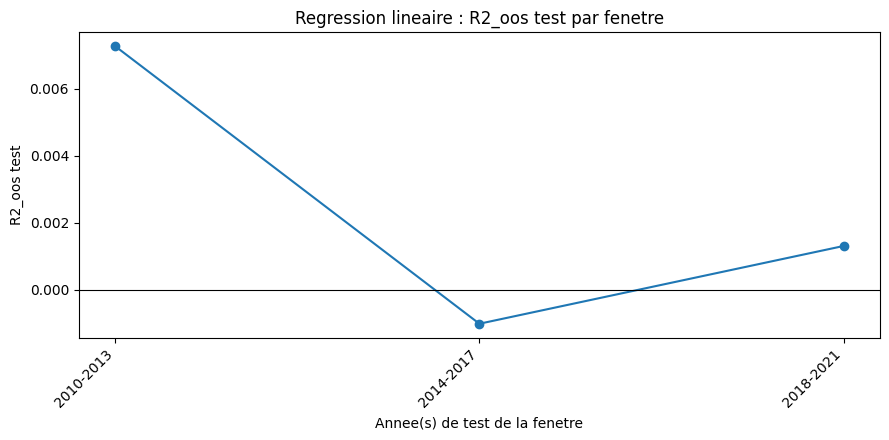

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(resultats_par_fenetre['annee_test'], resultats_par_fenetre['r2_oos_test'], marker='o')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel("Annee(s) de test de la fenetre")
ax.set_ylabel("R2_oos test")
ax.set_title("Regression lineaire : R2_oos test par fenetre")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 6. Coup d'œil rapide aux coefficients (modèle de la dernière fenêtre)

Les coefficients du modèle de la **dernière fenêtre** (celui qui a vu le plus de données,
et celui sauvegardé en `.joblib`) — un simple instantané, pas un test de significativité.
Voir la section 6bis pour une évaluation rigoureuse, stable dans le temps.

In [6]:
coefficients = rap.table('coefficients_derniere_fenetre')['coefficient']

print(f"Nombre de variables ramenees exactement a 0 : {rap.valeur('n_coefficients_a_zero')} / "
      f"{rap.valeur('n_predicteurs')} (normal : la regression lineaire simple n'en met jamais a 0)")
print()
print("Top 15 des variables les plus importantes (en valeur absolue) :")
coefficients.head(15)

Nombre de variables ramenees exactement a 0 : 0 / 30 (normal : la regression lineaire simple n'en met jamais a 0)

Top 15 des variables les plus importantes (en valeur absolue) :


turn        -0.013414
std_turn     0.009998
zerotrade   -0.009921
retvol      -0.005811
mom6m        0.004934
dolvol      -0.004546
chmom       -0.003581
indmom       0.003452
beta         0.003366
mom12m       0.003319
mom1m       -0.003138
bm           0.002988
agr          0.002780
ep           0.002132
gma          0.002079
Name: coefficient, dtype: float64

## 6bis. Significativité des variables (Fama-MacBeth 1973, t-stats de Newey-West)

La section précédente ne regarde que les coefficients de la **dernière fenêtre** — ça ne dit
rien sur leur **stabilité dans le temps** ni sur leur **significativité**. Deux mauvaises
idées pour combler ça :

- **Un OLS pooled sur les ~N×T lignes du panel** donnerait des t-stats complètement gonflées :
  les résidus sont fortement corrélés **entre entreprises d'un même mois** (mêmes chocs de
  marché), donc le nombre d'observations effectivement indépendantes est bien plus proche du
  nombre de **mois** que du nombre de lignes (Petersen, 2009).
- **Les coefficients d'une seule fenêtre** (section 6) ne sont qu'un instantané.

**La solution standard : Fama-MacBeth (1973).** Chaque **mois**, une régression en coupe
transversale du rendement excédentaire sur les caractéristiques (T régressions au total) ;
puis moyenne temporelle des T coefficients de chaque caractéristique, avec un écart-type de
**Newey-West** (robuste à l'autocorrélation et l'hétéroscédasticité) pour un t-stat valide.

⚠️ **Les 8 prédicteurs macro sont exclus.** Une régression cross-sectionnelle mensuelle n'a
par construction **aucune variance à expliquer** sur une variable macro : elle prend la même
valeur pour toutes les entreprises d'un mois donné, donc elle est parfaitement colinéaire
avec la constante — son coefficient n'est pas identifiable mois par mois.

ℹ️ **Portée** : contrairement aux sections 1 à 5, cette analyse utilise **tout l'historique
disponible**, pas seulement le train d'une fenêtre. C'est volontaire : l'objectif est
descriptif (quelles caractéristiques sont, en moyenne et de façon fiable, associées au
rendement futur), pas de ré-évaluer la capacité prédictive hors-échantillon.

In [7]:
if not rap.valeur('fama_macbeth_execute'):
    print("La section 6bis n'a pas ete calculee (script lance avec --sans-fama-macbeth).")
    print("Relance : python scripts/etape04_modele_lineaire.py")
else:
    significativite = pd.read_parquet(config.FICHIER_SIGNIFICATIVITE_REGRESSION_LINEAIRE)

    print(f"{rap.valeur('fm_n_regressions')} regressions cross-sectionnelles mensuelles estimees "
          f"({rap.valeur('fm_n_predicteurs')} predicteurs, periode "
          f"{rap.valeur('fm_periode')[0]} a {rap.valeur('fm_periode')[1]}).")
    print(f"Nombre de lags Newey-West : {rap.valeur('fm_nb_lags_nw')}")
    print()
    print(f"{rap.valeur('fm_nb_significatifs')} / {rap.valeur('fm_n_teste')} predicteurs "
          "significatifs a 5% (t-stat de Newey-West).")
    print("⚠️ Avec autant de tests simultanes, une partie de ces significativites est attendue par")
    print("   pur hasard (pas de correction de Bonferroni/FDR ici) -- a lire comme un classement")
    print("   indicatif, pas comme une liste 'certifiee'.")
    print()
    print("Top 20 des predicteurs les plus significatifs (|t-stat| decroissant) :")
    display(significativite.head(20).round(4))

503 regressions cross-sectionnelles mensuelles estimees (30 predicteurs, periode 198002 a 202112).
Nombre de lags Newey-West : 5

15 / 30 predicteurs significatifs a 5% (t-stat de Newey-West).
⚠️ Avec autant de tests simultanes, une partie de ces significativites est attendue par
   pur hasard (pas de correction de Bonferroni/FDR ici) -- a lire comme un classement
   indicatif, pas comme une liste 'certifiee'.

Top 20 des predicteurs les plus significatifs (|t-stat| decroissant) :


,coef_moyen_fm,erreur_type_nw,t_stat_nw,p_value_nw,pct_mois_signe_positif,significatif_5pct
predicteur,,,,,,
turn,-0.0091,0.0010,-8.7860,0.0000,27.0378,True
std_turn,0.0054,0.0007,7.8598,0.0000,65.8052,True
retvol,-0.0067,0.0010,-6.7872,0.0000,37.7734,True
mom1m,-0.0056,0.0009,-6.4001,0.0000,36.1829,True
zerotrade,-0.0057,0.0010,-5.8895,0.0000,37.7734,True
agr,0.0019,0.0003,5.5731,0.0000,61.6302,True
indmom,0.0035,0.0006,5.5257,0.0000,63.4195,True
gma,0.0025,0.0006,4.5510,0.0000,60.2386,True
mom6m,0.0030,0.0008,3.6766,0.0002,61.0338,True


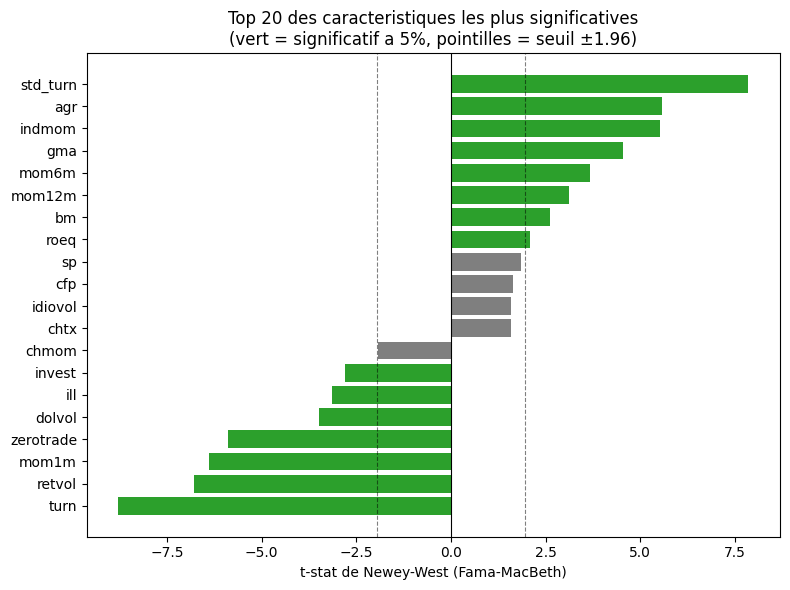

In [8]:
if rap.valeur('fama_macbeth_execute'):
    top20 = significativite.head(20).sort_values('t_stat_nw')
    couleurs = ['tab:green' if s else 'tab:gray' for s in top20['significatif_5pct']]

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(top20.index, top20['t_stat_nw'], color=couleurs)
    ax.axvline(0, color='black', linewidth=0.8)
    for seuil in (-1.96, 1.96):
        ax.axvline(seuil, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_xlabel("t-stat de Newey-West (Fama-MacBeth)")
    ax.set_title("Top 20 des caracteristiques les plus significatives\n"
                 "(vert = significatif a 5%, pointilles = seuil ±1.96)")
    plt.tight_layout()
    plt.show()

## 7 & 8. Ce que le script a sauvegardé, et le journal des expériences

Trois sauvegardes, chacune avec un rôle différent :
- **Le modèle final** (`.joblib`) : celui de la dernière fenêtre, à titre de référence /
  pour prédire au-delà des données actuelles — **pas** utilisé pour l'évaluation.
- **Les prédictions pooled** (une ligne par `permno`/`annee_mois` de test, toutes fenêtres
  confondues) : c'est ce que consomme le notebook 07 pour les portefeuilles par décile.
- **Les résultats** : un résumé pooled (une ligne) et un détail par fenêtre.

En plus, une ligne est ajoutée au **journal des expériences**
(`outputs/journal_experiences.parquet`, jamais écrasé) : c'est ce qui permet au notebook 08
de comparer ce lancement à d'autres jeux de paramètres, sans rien relancer. Relancer le
script avec exactement les mêmes paramètres n'ajoute jamais de doublon.

⚠️ La colonne `cle_experience` de `resultats_finaux` est **la même clé** que celle du
journal : le notebook 07 la relit pour taguer ses mesures de portefeuille, ce qui permet au
notebook 08 d'associer le Sharpe/Sortino de **ce** lancement à la bonne ligne de son tableau.

In [9]:
print("Modele final (derniere fenetre) :", config.FICHIER_MODELE_REGRESSION_LINEAIRE)
print("Predictions (toutes fenetres)   :", config.FICHIER_PREDICTIONS_REGRESSION_LINEAIRE)
print("Resultats pooled                :", config.FICHIER_RESULTATS_REGRESSION_LINEAIRE)
print("Resultats par fenetre           :", config.FICHIER_RESULTATS_REGRESSION_LINEAIRE_PAR_FENETRE)
print()
print("Cle de cette experience :", rap.valeur('cle_experience'))
print("Parametres specifiques  :", rap.valeur('params_specifiques'), "(OLS : aucun)")
if rap.valeur('experience_ajoutee_au_journal'):
    print("-> ligne AJOUTEE au journal des experiences.")
else:
    print("-> experience deja presente dans le journal (memes parametres qu'un lancement precedent),")
    print("   rien n'a ete ajoute : pas de doublon.")
print()
print("Apercu des predictions sauvegardees :")
rap.table('apercu_predictions')

Modele final (derniere fenetre) : C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\Memoire\modeles\regression_lineaire.joblib
Predictions (toutes fenetres)   : C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\Memoire\outputs\predictions_regression_lineaire.parquet
Resultats pooled                : C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\Memoire\outputs\resultats_regression_lineaire.parquet
Resultats par fenetre           : C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\Memoire\outputs\resultats_regression_lineaire_par_fenetre.parquet

Cle de cette experience : 9f807ccf6d8834e1
Parametres specifiques  : {} (OLS : aucun)
-> ligne AJOUTEE au journal des experiences.

Apercu des predictions sauvegardees :


,permno,annee_mois,excess_return,prediction,fenetre
0,10001,201001,-0.018932,0.005855,0
1,10002,201001,0.365854,-0.011612,0
2,10025,201001,-0.088036,0.016756,0
3,10026,201001,0.046296,-0.000642,0
4,10032,201001,0.194171,0.016989,0


## 9. Résumé

- Régression linéaire simple (OLS), **sans régularisation et sans hyperparamètre** —
  ré-entraînée à chaque fenêtre, jamais une seule fois sur tout l'historique.
- Même métrique (`R²_oos` à la GKX, pooled) et même logique de fenêtres que les autres
  modèles du projet, pour rester comparable.
- Aucun coefficient n'est mis à 0 : toutes les variables sont gardées, y compris celles qui
  n'apportent rien — à comparer avec l'Elastic Net au notebook suivant.
- **Significativité (section 6bis)** : Fama-MacBeth + Newey-West, beaucoup plus fiable qu'un
  coefficient de la dernière fenêtre ou qu'un p-value d'OLS pooled (invalide ici).

**Étape suivante :** `python scripts/etape05_modele_elastic_net.py`.